Title: LEE_ERA5_temporal_evolution.ipynb

Purpose: Look how the ERA5 data changed over time

Author: Onno Nennecke on 23.07.2026 Modified: 23.07.2026

Input data: 

- ERA5 LEE Tables: LEE_dat_ERA5_1960_.csv, LEE_dat_7_selection_ERA5_1960_.csv, LEE_dat_14_selection_ERA5_1960_.csv, LEE_vl_ERA5_1960_.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- ERA5_hist_timeseries
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_all_years/ERA5_hist_timeseries.nc'


Output data:

- Plots: ERA5_RT_TS
    - These files lie here: /home/onennecke/Code/Figures/ERA5_RT_TS.png


In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import seaborn as sns

from scipy import stats


In [2]:
# Function to add a winter season column
def add_winter_season_column(df):
    # Ensure 'date_start' is in datetime format
    df['date_start'] = pd.to_datetime(df['date_start'])
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    
    # Apply the function to create a new 'winter_season' column
    df['winter_season'] = df['date_start'].apply(get_winter_season)
    
    df['season_year'] = df['winter_season'].apply(lambda x: int(x.split('/')[0])) + 2000
    
    return df

### Read LEE data

In [3]:
# Read the LEE data
LEE_dat_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_ERA5_1960_.csv')
LEE_dat_ERA5_1960_ = add_winter_season_column(LEE_dat_ERA5_1960_)
LEE_dat_7_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_ERA5_1960_.csv')
LEE_dat_7_ERA5_1960_ = add_winter_season_column(LEE_dat_7_ERA5_1960_)
LEE_dat_14_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_ERA5_1960_.csv')
LEE_dat_14_ERA5_1960_ = add_winter_season_column(LEE_dat_14_ERA5_1960_)
LEE_vl_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_ERA5_1960_.csv')
LEE_vl_ERA5_1960_ = add_winter_season_column(LEE_vl_ERA5_1960_)


## Trend of RL over time

### Only VRES days

Slope: -0.0005640522356813105, Intercept: 1387.5362234098106, R-squared: 0.006660717436883203, P-value: 0.002520520209537376


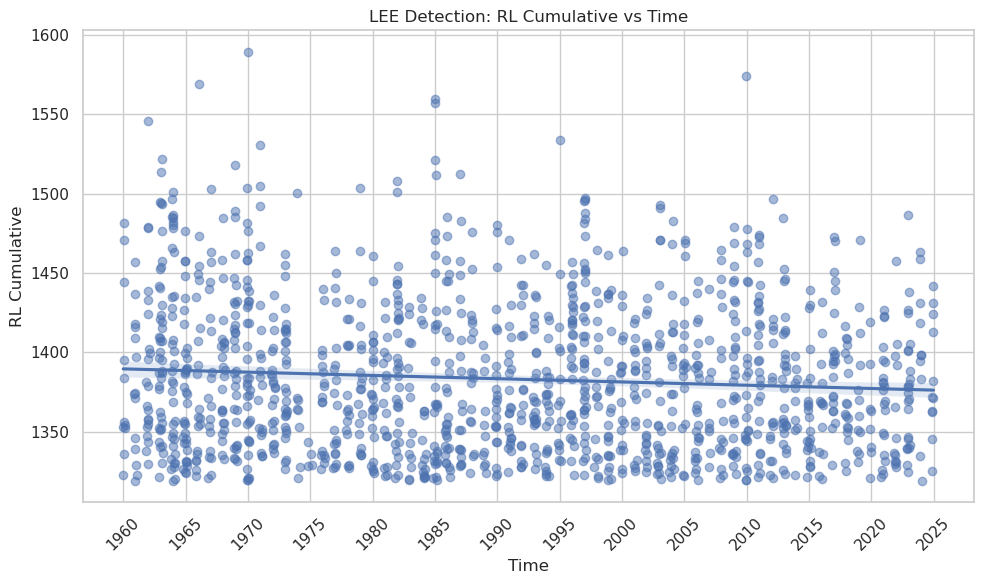

Slope: -0.1376, Intercept: 1384.71, R²: 0.0394, P-value: 0.1103


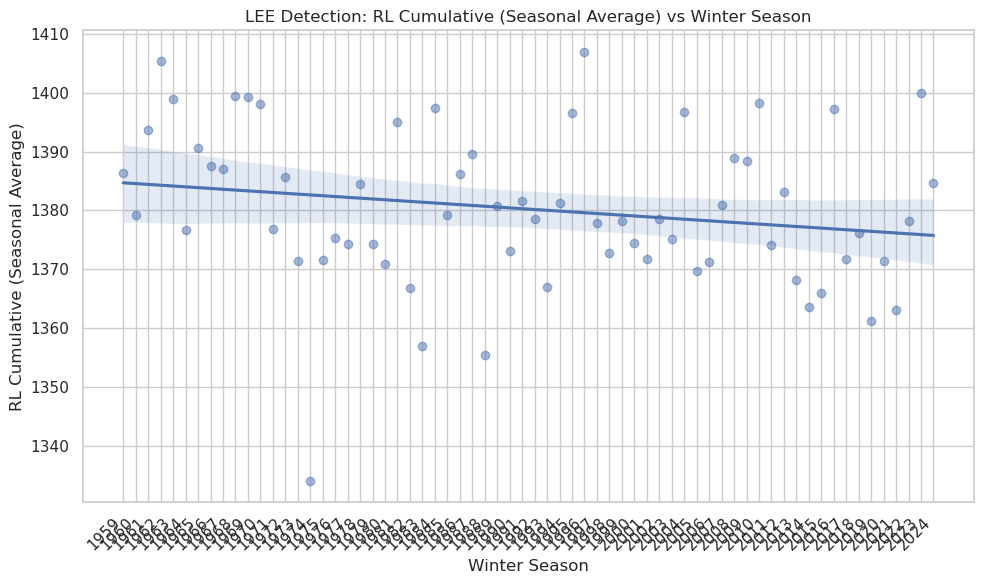

Slope: -0.1963, Intercept: 1773.05, R²: 0.6899, P-value: 0.0207


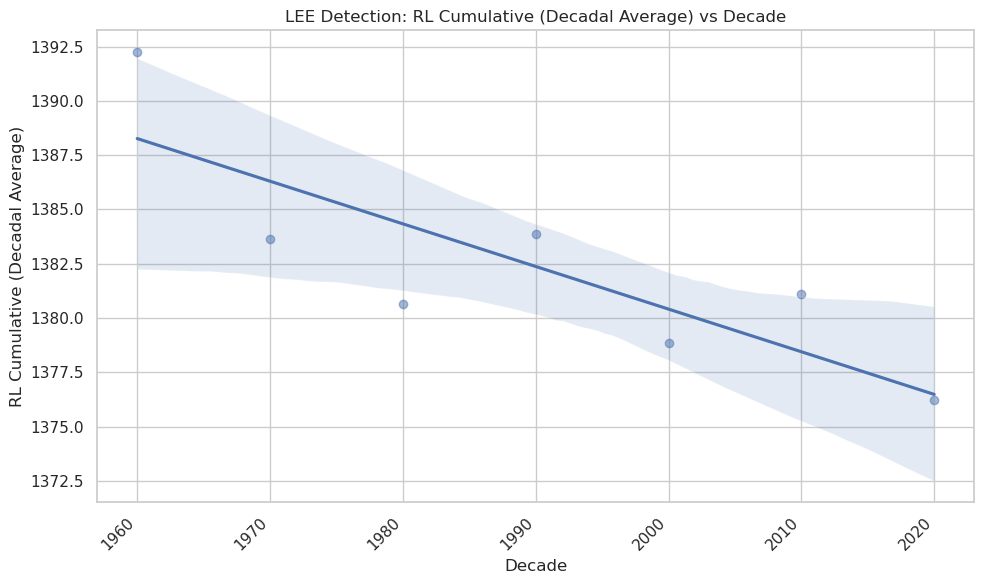

In [4]:
# Plot LEE_dat_ERA5_1960_['RL_cumulative'] vs time and make a regression line with seaborn and matplotlib



df = LEE_dat_ERA5_1960_.copy()
df['date_num'] = pd.to_datetime(df['date_start']).map(mdates.date2num)

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(x='date_num', y='RL_cumulative', data=df,
            scatter_kws={'alpha': 0.5}, ax=ax)

# Show statistics of the regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(df['date_num'], df['RL_cumulative'])
print(f"Slope: {slope}, Intercept: {intercept}, R-squared: {r_value**2}, P-value: {p_value}")

# Convert numeric x ticks back to readable dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
plt.xticks(rotation=45)

ax.set_xlabel('Time')
ax.set_ylabel('RL Cumulative')
ax.set_title('LEE Detection: RL Cumulative vs Time')
plt.tight_layout()
plt.show()


# Make the same thing but with seasonally averaged data (mean of each winter season) and plot it with seaborn and matplotlib
df_seasonal = (LEE_dat_ERA5_1960_['RL_cumulative']
               .groupby(LEE_dat_ERA5_1960_['season_year'])
               .mean()
               .reset_index())

df_seasonal['x_num'] = range(len(df_seasonal))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_seasonal['x_num'], df_seasonal['RL_cumulative']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, "
      f"R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='x_num', y='RL_cumulative', data=df_seasonal,
            scatter_kws={'alpha': 0.5}, ax=ax)

ax.set_xticks(df_seasonal['x_num'])
ax.set_xticklabels(df_seasonal['season_year'], rotation=45, ha='right')
ax.set_xlabel('Winter Season')
ax.set_ylabel('RL Cumulative (Seasonal Average)')
ax.set_title('LEE Detection: RL Cumulative (Seasonal Average) vs Winter Season')
plt.tight_layout()
plt.show()

# Same thing for 10 year blocks (1960-1969, 1970-1979, 1980-1989, 1990-1999, 2000-2009, 2010-2019)
df_decadal = (LEE_dat_ERA5_1960_['RL_cumulative']
              .groupby(((LEE_dat_ERA5_1960_['season_year']+1) // 10) * 10)
              .mean()
              .reset_index())
df_decadal.rename(columns={'season_year': 'decade'}, inplace=True)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_decadal['decade'], df_decadal['RL_cumulative']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='decade', y='RL_cumulative', data=df_decadal,
            scatter_kws={'alpha': 0.5}, ax=ax)
ax.set_xticks(df_decadal['decade'])
ax.set_xticklabels(df_decadal['decade'], rotation=45, ha='right')
ax.set_xlabel('Decade')
ax.set_ylabel('RL Cumulative (Decadal Average)')
ax.set_title('LEE Detection: RL Cumulative (Decadal Average) vs Decade')
plt.tight_layout()
plt.show()

Slope: -0.1130, Intercept: 24.40, R²: 0.0733, P-value: 0.0279


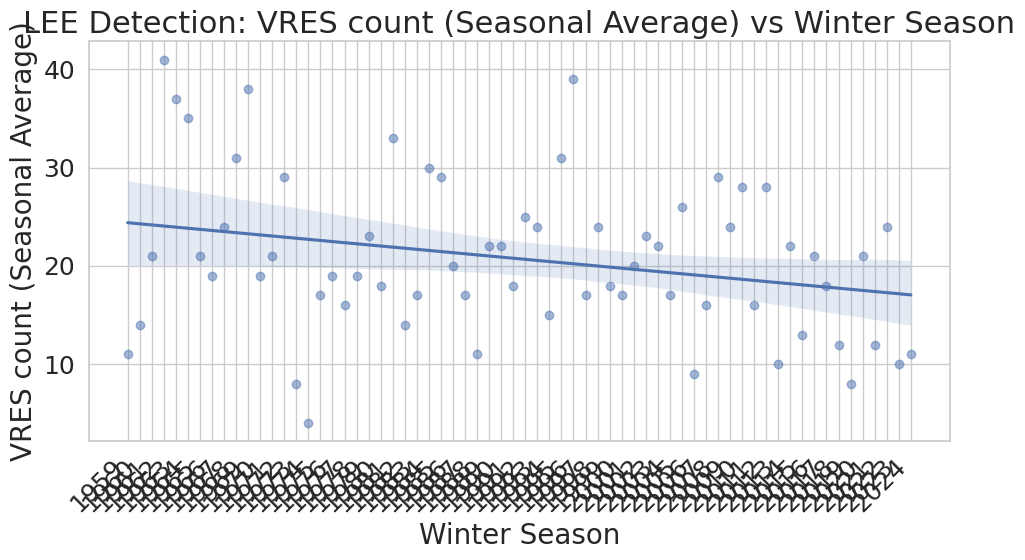

In [6]:
# Make the same thing but with seasonally averaged data and the count of events per season
df_seasonal = (LEE_dat_ERA5_1960_['RL_cumulative']
               .groupby(LEE_dat_ERA5_1960_['season_year'])
               .count()
               .reset_index())

df_seasonal['x_num'] = range(len(df_seasonal))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_seasonal['x_num'], df_seasonal['RL_cumulative']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, "
      f"R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='x_num', y='RL_cumulative', data=df_seasonal,
            scatter_kws={'alpha': 0.5}, ax=ax)

ax.set_xticks(df_seasonal['x_num'])
ax.set_xticklabels(df_seasonal['season_year'], rotation=45, ha='right')
ax.set_xlabel('Winter Season')
ax.set_ylabel('VRES count (Seasonal Average)')
ax.set_title('LEE Detection: VRES count (Seasonal Average) vs Winter Season')
plt.tight_layout()
plt.show()


Slope: 0.1138, Intercept: -218.62, R²: 0.4571, P-value: 0.0954


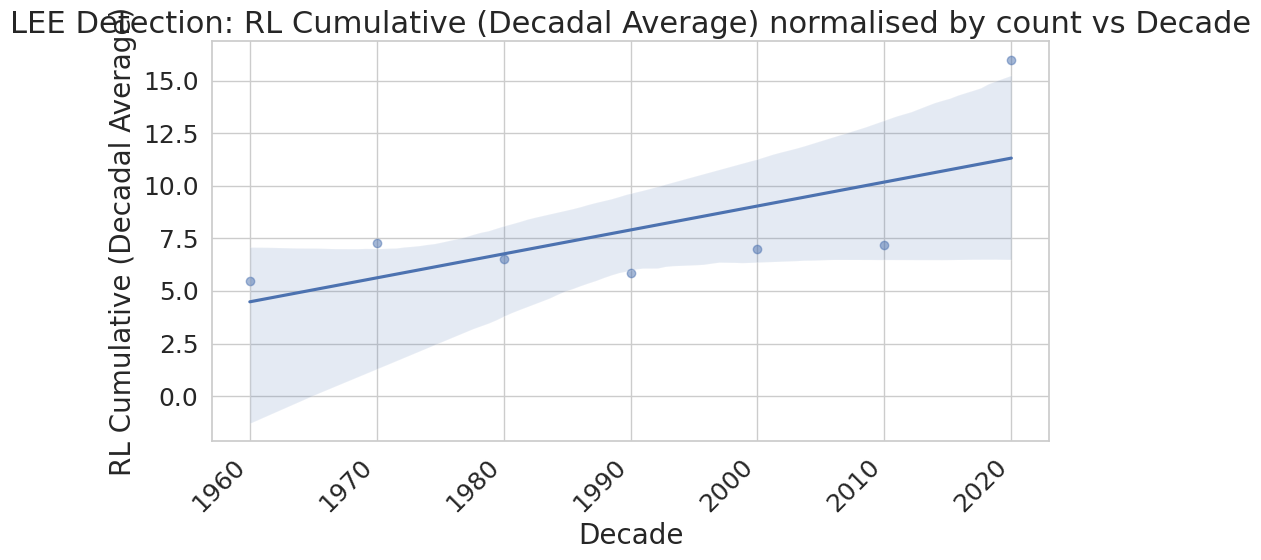

In [7]:
(LEE_dat_ERA5_1960_['RL_cumulative']
              .groupby(((LEE_dat_ERA5_1960_['season_year']+1) // 10) * 10)
              .count()
              .reset_index())
# Plot 
df_decadal = (LEE_dat_ERA5_1960_['RL_cumulative']
              .groupby(((LEE_dat_ERA5_1960_['season_year']+1) // 10) * 10)
              .mean()
              .reset_index())

df_count = (LEE_dat_ERA5_1960_['RL_cumulative']
              .groupby(((LEE_dat_ERA5_1960_['season_year']+1) // 10) * 10)
              .count()
              .reset_index())

df_decadal['RL_cumulative'] = df_decadal['RL_cumulative'] / df_count['RL_cumulative']

df_decadal.rename(columns={'season_year': 'decade'}, inplace=True)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_decadal['decade'], df_decadal['RL_cumulative']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='decade', y='RL_cumulative', data=df_decadal,
            scatter_kws={'alpha': 0.5}, ax=ax)
ax.set_xticks(df_decadal['decade'])
ax.set_xticklabels(df_decadal['decade'], rotation=45, ha='right')
ax.set_xlabel('Decade')
ax.set_ylabel('RL Cumulative (Decadal Average)')
ax.set_title('LEE Detection: RL Cumulative (Decadal Average) normalised by count vs Decade')
plt.tight_layout()
plt.show()


In [8]:
df_60 = LEE_dat_ERA5_1960_.copy()
df_ERA5_1960_1990 = df_60[(df_60['season_year'] < 1990)]
df_ERA5_1990_2014 = df_60[(df_60['season_year'] >= 1990) & (df_60['season_year'] < 2014)]

print(df_ERA5_1960_1990['RL_cumulative'].mean())
print(df_ERA5_1990_2014['RL_cumulative'].mean())


1385.8396885243428
1382.4433096738521


---

## Now the whole thing again for all days, not just VRES days

In [9]:
# Function to add a winter season coordinate to an xarray Dataset
def add_winter_season_coordinate(ds, time_dim='time'):
    # Ensure the time coordinate is in datetime format
    time_values = pd.to_datetime(ds[time_dim].values)
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    # def get_winter_season(date):
    #     year = date.year
    #     if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
    #         return year
    #     else:  # January, February, March, April, May, June belong to the current year's winter
    #         return year-1
    # Apply the function to create a new array of winter seasons
    winter_seasons = np.array([get_winter_season(date) for date in time_values])

    # Add the new coordinate to the Dataset
    ds = ds.assign_coords(winter_season=(time_dim, winter_seasons))
    return ds

In [10]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_all_years/ERA5_hist_timeseries.nc'

ts_datasets_ERA5 = xr.open_dataset(path)
ts_datasets_ERA5 = add_winter_season_coordinate(ts_datasets_ERA5, time_dim='time')
ts_datasets_ERA5.load()
res_load_ERA5 = ts_datasets_ERA5['Residual_load']

res_load_ERA5_7d = res_load_ERA5.rolling(time=7, center=False).mean()
res_load_ERA5_14d = res_load_ERA5.rolling(time=14, center=False).mean()

In [11]:
res_load_ERA5_1960_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2014 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year <= 2014), drop=True)['Residual_load']

res_load_ERA5_1960_1970 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1970), drop=True)['Residual_load']
res_load_ERA5_1970_1980 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1970) & (ts_datasets_ERA5.time.dt.year < 1980), drop=True)['Residual_load']
res_load_ERA5_1980_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1980) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2000 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year < 2000), drop=True)['Residual_load']
res_load_ERA5_2000_2010 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2000) & (ts_datasets_ERA5.time.dt.year < 2010), drop=True)['Residual_load']
res_load_ERA5_2010_2020 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2010) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']
res_load_ERA5_2020_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2020) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']

res_load_ERA5_2015_2019 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']

In [12]:
RLs = [res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]

means = [np.mean(rl.values) for rl in RLs]
means



[np.float64(860.1621306403575),
 np.float64(859.4199188776411),
 np.float64(839.95045701852),
 np.float64(815.5844556709305),
 np.float64(834.3953956698805),
 np.float64(841.3180129912308),
 np.float64(825.7675504187749)]

## All days

Slope: -0.001454, Intercept: 852.52, R²: 0.0008, P-value: 0.0000


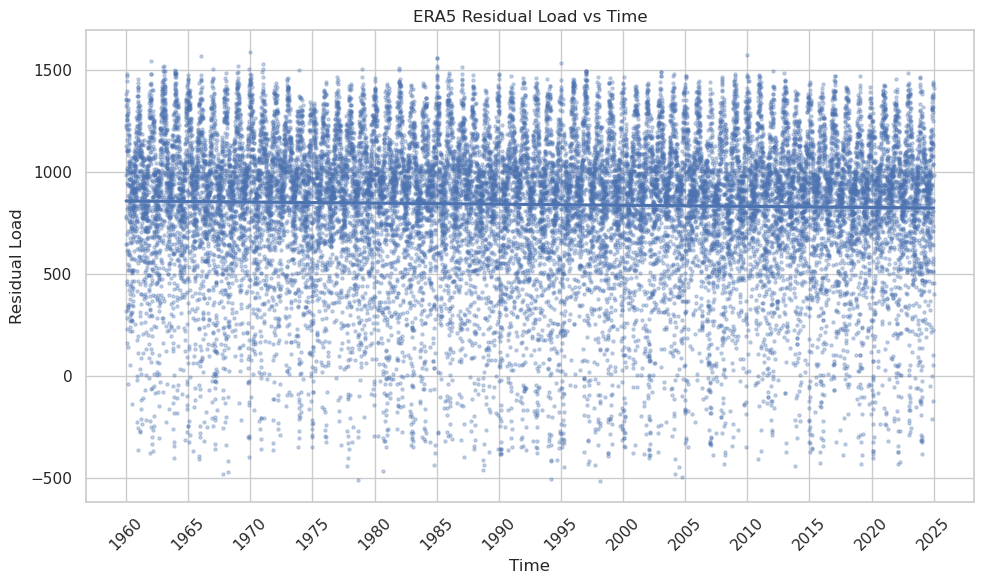

Slope: -0.4746, Intercept: 856.17, R²: 0.0436, P-value: 0.0926


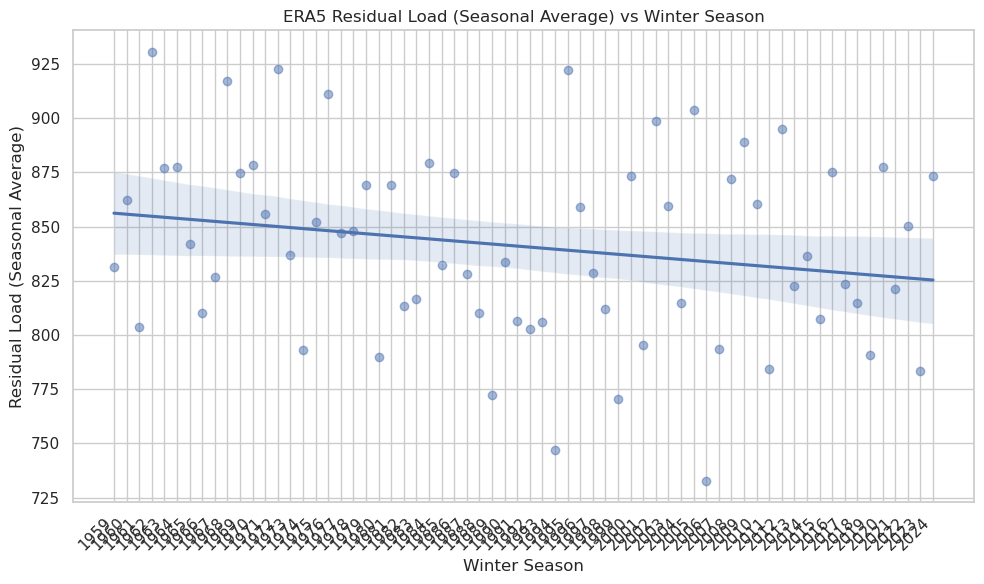

Slope: -0.5177, Intercept: 1869.64, R²: 0.4649, P-value: 0.0916


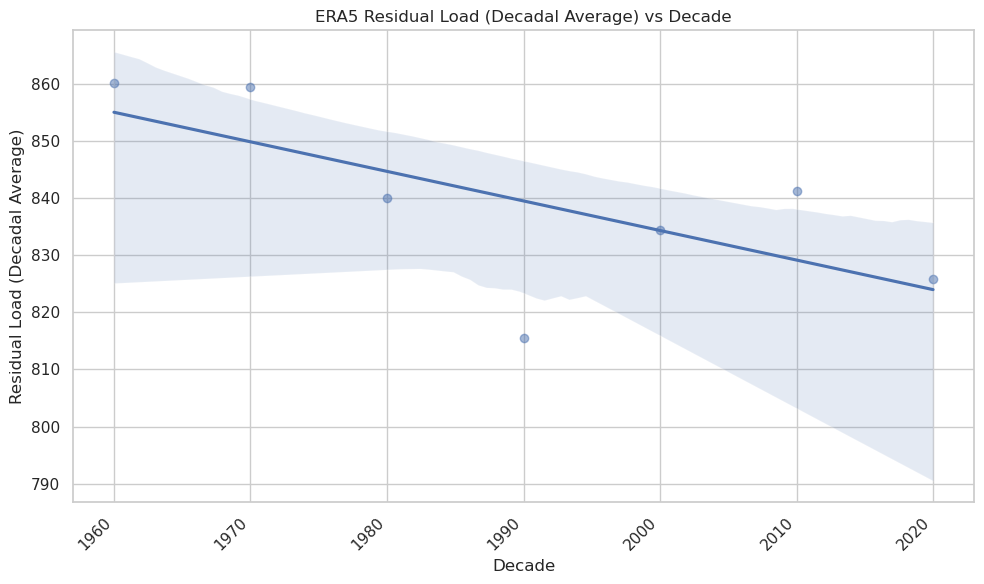

In [13]:
# Convert xarray to dataframe
df = ts_datasets_ERA5[['Residual_load']].to_dataframe().reset_index()
df['date_num'] = df['time'].map(mdates.date2num)
df['year'] = df['time'].dt.year
df['winter_season'] = ts_datasets_ERA5['winter_season'].values 

df['winter_year'] = [int(s.split('/')[0]) + 2000 for s in df['winter_season']]

# ── Plot 1: Raw time series with regression ───────────────────────────────────
slope, intercept, r_value, p_value, std_err = stats.linregress(df['date_num'], df['Residual_load'])
print(f"Slope: {slope:.6f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='date_num', y='Residual_load', data=df,
            scatter_kws={'alpha': 0.3, 's': 5}, ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
plt.xticks(rotation=45)
ax.set_xlabel('Time')
ax.set_ylabel('Residual Load')
ax.set_title('ERA5 Residual Load vs Time')
plt.tight_layout()
plt.show()

# ── Plot 2: Seasonal averages ─────────────────────────────────────────────────
df_seasonal = df.groupby('winter_year')['Residual_load'].mean().reset_index()
df_seasonal['x_num'] = range(len(df_seasonal))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_seasonal['x_num'], df_seasonal['Residual_load']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='x_num', y='Residual_load', data=df_seasonal,
            scatter_kws={'alpha': 0.5}, ax=ax)
ax.set_xticks(df_seasonal['x_num'])
ax.set_xticklabels(df_seasonal['winter_year'], rotation=45, ha='right')
ax.set_xlabel('Winter Season')
ax.set_ylabel('Residual Load (Seasonal Average)')
ax.set_title('ERA5 Residual Load (Seasonal Average) vs Winter Season')
plt.tight_layout()
plt.show()

# ── Plot 3: Decadal averages ──────────────────────────────────────────────────
df['decade'] = (df['year'] // 10) * 10
df_decadal = df.groupby('decade')['Residual_load'].mean().reset_index()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_decadal['decade'], df_decadal['Residual_load']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='decade', y='Residual_load', data=df_decadal,
            scatter_kws={'alpha': 0.5}, ax=ax)
ax.set_xticks(df_decadal['decade'])
ax.set_xticklabels(df_decadal['decade'], rotation=45, ha='right')
ax.set_xlabel('Decade')
ax.set_ylabel('Residual Load (Decadal Average)')
ax.set_title('ERA5 Residual Load (Decadal Average) vs Decade')
plt.tight_layout()
plt.show()

## Extended winter season

Slope: -0.002636, Intercept: 897.56, R²: 0.0017, P-value: 0.0000


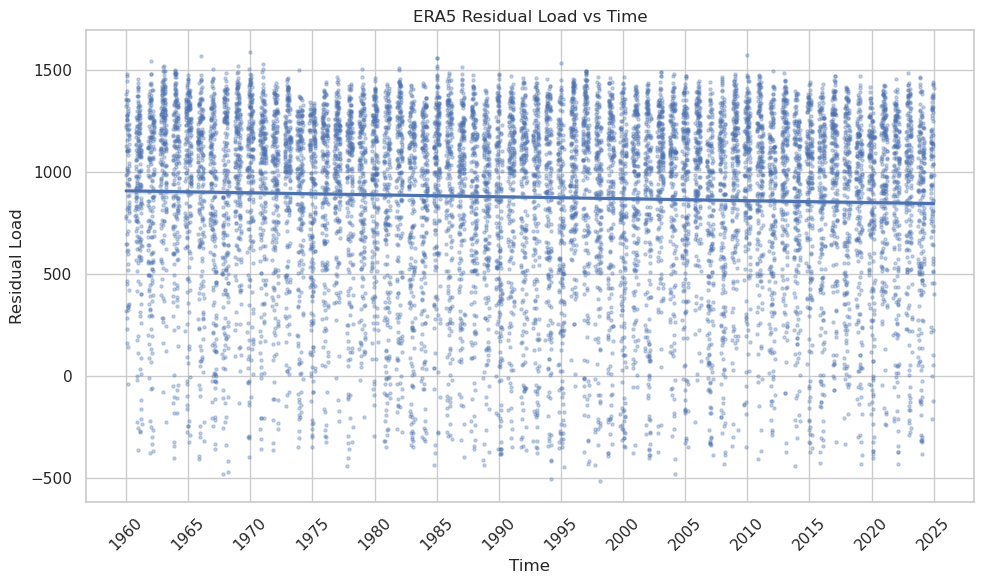

Slope: -0.9203, Intercept: 906.74, R²: 0.0476, P-value: 0.0784


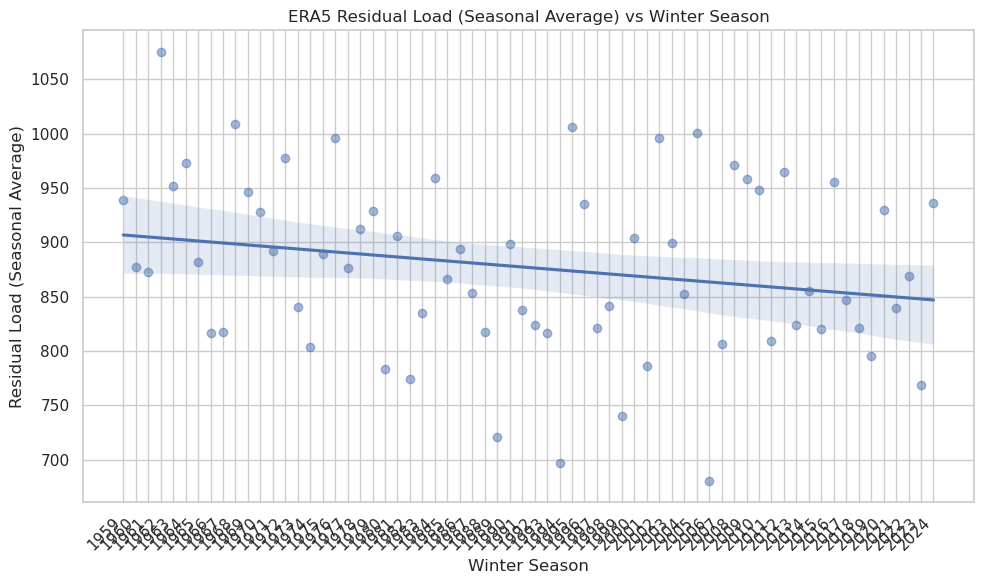

Slope: -0.9749, Intercept: 2813.43, R²: 0.4572, P-value: 0.0954


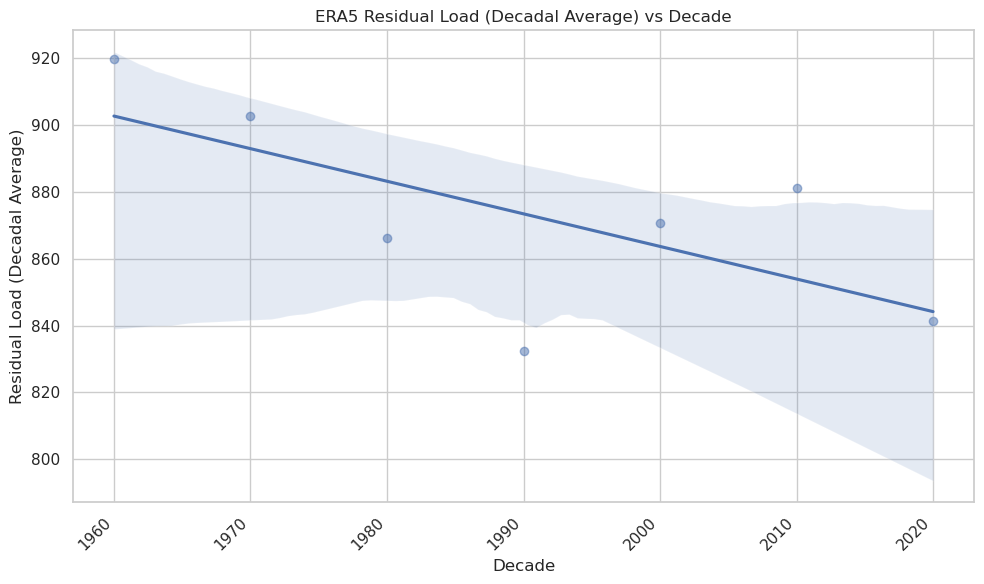

In [14]:
# Convert xarray to dataframe
df = ts_datasets_ERA5[['Residual_load']].to_dataframe().reset_index()

df['date_num'] = df['time'].map(mdates.date2num)
df['year'] = df['time'].dt.year
df['winter_season'] = ts_datasets_ERA5['winter_season'].values 

df['winter_year'] = [int(s.split('/')[0]) + 2000 for s in df['winter_season']]

# Filter only extended winter season (October to March)
df = df[(df['time'].dt.month >= 10) | (df['time'].dt.month <= 3)]

# ── Plot 1: Raw time series with regression ───────────────────────────────────
slope, intercept, r_value, p_value, std_err = stats.linregress(df['date_num'], df['Residual_load'])
print(f"Slope: {slope:.6f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='date_num', y='Residual_load', data=df,
            scatter_kws={'alpha': 0.3, 's': 5}, ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
plt.xticks(rotation=45)
ax.set_xlabel('Time')
ax.set_ylabel('Residual Load')
ax.set_title('ERA5 Residual Load vs Time')
plt.tight_layout()
plt.show()

# ── Plot 2: Seasonal averages ─────────────────────────────────────────────────
df_seasonal = df.groupby('winter_year')['Residual_load'].mean().reset_index()
df_seasonal['x_num'] = range(len(df_seasonal))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_seasonal['x_num'], df_seasonal['Residual_load']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='x_num', y='Residual_load', data=df_seasonal,
            scatter_kws={'alpha': 0.5}, ax=ax)
ax.set_xticks(df_seasonal['x_num'])
ax.set_xticklabels(df_seasonal['winter_year'], rotation=45, ha='right')
ax.set_xlabel('Winter Season')
ax.set_ylabel('Residual Load (Seasonal Average)')
ax.set_title('ERA5 Residual Load (Seasonal Average) vs Winter Season')
plt.tight_layout()
plt.show()

# ── Plot 3: Decadal averages ──────────────────────────────────────────────────
df['decade'] = (df['year'] // 10) * 10
df_decadal = df.groupby('decade')['Residual_load'].mean().reset_index()

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_decadal['decade'], df_decadal['Residual_load']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='decade', y='Residual_load', data=df_decadal,
            scatter_kws={'alpha': 0.5}, ax=ax)
ax.set_xticks(df_decadal['decade'])
ax.set_xticklabels(df_decadal['decade'], rotation=45, ha='right')
ax.set_xlabel('Decade')
ax.set_ylabel('Residual Load (Decadal Average)')
ax.set_title('ERA5 Residual Load (Decadal Average) vs Decade')
plt.tight_layout()
plt.show()

In [15]:
# Function to add a winter season coordinate to an xarray Dataset
def add_winter_season_coordinate(ds, time_dim='time'):
    # Ensure the time coordinate is in datetime format
    time_values = pd.to_datetime(ds[time_dim].values)
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    # def get_winter_season(date):
    #     year = date.year
    #     if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
    #         return year
    #     else:  # January, February, March, April, May, June belong to the current year's winter
    #         return year-1
    # Apply the function to create a new array of winter seasons
    winter_seasons = np.array([get_winter_season(date) for date in time_values])

    # Add the new coordinate to the Dataset
    ds = ds.assign_coords(winter_season=(time_dim, winter_seasons))
    return ds

In [16]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)
ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ts_datasets_ERA5.load()
res_load_era5_15_24 = ts_datasets_ERA5['Residual_load']
res_load_era5_15_24_1d = res_load_era5_15_24.values.ravel()

res_load_era5_15_24_7d = res_load_era5_15_24.rolling(time=7, center=False).mean()
res_load_era5_15_24_14d = res_load_era5_15_24.rolling(time=14, center=False).mean()

ts_datasets_curr_clim = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist') & (ds.ESM_run != 'ERA5_hist_week'),drop=True)
ts_datasets_curr_clim.load()

res_load_curr_clim = ts_datasets_curr_clim['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_curr_clim_1d = res_load_curr_clim.values.ravel()

res_load_curr_clim_7d = res_load_curr_clim.rolling(time=7, center=False).mean()
res_load_curr_clim_14d = res_load_curr_clim.rolling(time=14, center=False).mean()


In [17]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_all_years/ERA5_hist_timeseries.nc'

ts_datasets_ERA5 = xr.open_dataset(path)
ts_datasets_ERA5 = add_winter_season_coordinate(ts_datasets_ERA5, time_dim='time')
ts_datasets_ERA5.load()
res_load_ERA5 = ts_datasets_ERA5['Residual_load']

res_load_ERA5_7d = res_load_ERA5.rolling(time=7, center=False).mean()
res_load_ERA5_14d = res_load_ERA5.rolling(time=14, center=False).mean()

In [18]:
res_load_ERA5_1960_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2014 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year <= 2014), drop=True)['Residual_load']

res_load_ERA5_1960_1970 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1970), drop=True)['Residual_load']
res_load_ERA5_1970_1980 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1970) & (ts_datasets_ERA5.time.dt.year < 1980), drop=True)['Residual_load']
res_load_ERA5_1980_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1980) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
res_load_ERA5_1990_2000 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year < 2000), drop=True)['Residual_load']
res_load_ERA5_2000_2010 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2000) & (ts_datasets_ERA5.time.dt.year < 2010), drop=True)['Residual_load']
res_load_ERA5_2010_2020 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2010) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']
res_load_ERA5_2020_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2020) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']

res_load_ERA5_2015_2019 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']

Slope: -0.1963, Intercept: 1773.05, R²: 0.6899, P-value: 0.0207


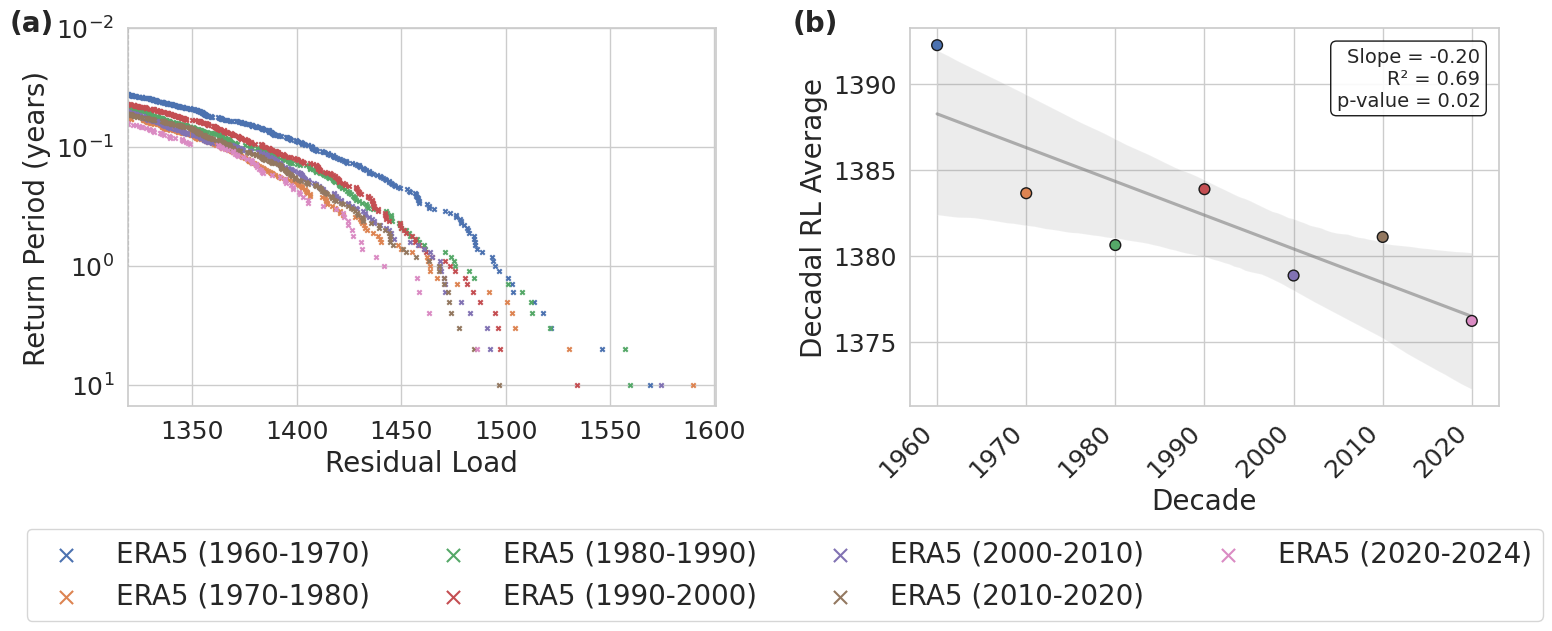

In [ ]:
mpl.rcParams.update({
    'font.size': 16+4,
    'axes.titlesize': 18+4,
    'axes.labelsize': 16+4,
    'xtick.labelsize': 14+4,
    'ytick.labelsize': 14+4,
    'legend.fontsize': 16+4,
})

RLs = [res_load_ERA5_1960_1970, res_load_ERA5_1970_1980, res_load_ERA5_1980_1990,
       res_load_ERA5_1990_2000, res_load_ERA5_2000_2010, res_load_ERA5_2010_2020, res_load_ERA5_2020_2024]
labels = ['ERA5 (1960-1970)', 'ERA5 (1970-1980)', 'ERA5 (1980-1990)',
          'ERA5 (1990-2000)', 'ERA5 (2000-2010)', 'ERA5 (2010-2020)', 'ERA5 (2020-2024)']


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------- (a) Return Time Plot ----------------
ax = axes[0]
label_color = {}  # map label -> color, so (b) can look it up reliably
for i, (res_load, label) in enumerate(zip(RLs, labels)):
    extremes = res_load
    x = np.sort(extremes)
    m = np.arange(1, len(x) + 1)
    N = len(extremes)
    T = 1 / (1 - (m / (N + 1))) / 365

    c = colors[i % len(colors)]
    label_color[label] = c
    ax.scatter(x, T, marker='x', s=10, label=label, color=c)

ax.vlines(1319.138650687668, ymin=0, ymax=1, color='gray', linestyle='--', linewidth=0.8)
ax.set_yscale('log')
ax.set_xlim(1319.138650687668, max(np.nanmax(rl) for rl in RLs) * 1.007)
ax.invert_yaxis()
ax.set_ylim(None, 10**-2)
ax.set_ylabel('Return Period (years)')
ax.set_xlabel('Residual Load')
# ax.set_title('Return Time Plot')
ax.grid(True)
ax.text(-0.2, 1.05, '(a)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# single shared legend under BOTH plots instead of overlapping one axis
handles, leg_labels = ax.get_legend_handles_labels()

# ---------------- (b) Decadal Trend Plot ----------------
ax2 = axes[1]

df_decadal = (LEE_dat_ERA5_1960_['RL_cumulative']
              .groupby(((LEE_dat_ERA5_1960_['season_year'] + 1) // 10) * 10)
              .mean()
              .reset_index())
df_decadal.rename(columns={'season_year': 'decade'}, inplace=True)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_decadal['decade'], df_decadal['RL_cumulative']
)
print(f"Slope: {slope:.4f}, Intercept: {intercept:.2f}, R²: {r_value**2:.4f}, P-value: {p_value:.4f}")

sns.regplot(x='decade', y='RL_cumulative', data=df_decadal,
            scatter=False, ax=ax2, color='gray', line_kws={'alpha': 0.6})

# Build decade -> label mapping explicitly instead of relying on row order.
# Adjust this if your decade values don't start at 1960 in steps of 10.
point_colors = [colors[i % len(colors)] for i in range(len(df_decadal))]
decade_labels = [f"{d}-{d+10}" for d in df_decadal['decade']]



ax2.scatter(df_decadal['decade'], df_decadal['RL_cumulative'],
            c=point_colors, s=60, edgecolor='k', zorder=3)

ax2.set_xticks(df_decadal['decade'])
ax2.set_xticklabels(df_decadal['decade'], rotation=45, ha='right')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Decadal RL Average')
textstr = '\n'.join((
        f'Slope = {slope:.2f}',
        # f'Intercept = {intercept:.2f}',
        f'R² = {r_value**2:.2f}',
        f'p-value = {p_value:.2f}'
    ))
ax2.text(2.3, 0.95, textstr, transform=ax.transAxes,
        va='top', ha='right', fontsize=14,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.9))

# ax2.set_title('LEE Detection: RL Cumulative (Decadal Average) vs Decade')
ax2.text(-0.2, 1.05, '(b)', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')

fig.legend(handles, leg_labels, loc='lower center', bbox_to_anchor=(0.5, -0.1),
           ncol=4, frameon=True, markerscale=3)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig('/home/onennecke/Code/Figures/ERA5_RT_TS.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:
res_load_ERA5_2015_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']
res_load_ERA5_2015_2024

<xarray.DataArray 'Residual_load' (time: 3650)> Size: 29kB
array([ 533.62954852, -124.66275289,  290.84286213, ...,  984.9126268 ,
        457.11872085,  402.62437437])
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U9 36B 'ERA5_week'
    run            <U4 16B 'hist'
    ESM_run        <U14 56B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    winter_season  (time) <U7 102kB '14/15' '14/15' '14/15' ... '24/25' '24/25'

In [15]:
# Connect both ERA5 periods to the same plot to see if they differ in the recent years (2015-2024)
res_load_tst = xr.concat([res_load_ERA5_2015_2019, res_load_ERA5_2020_2024], dim='time').values

# Check if they are exactly the same (they should be)
# np.allclose(res_load_tst, res_load_ERA5_2015_2024.values)


In [16]:
# Select values larger than threshold
threshold = np.float64(1319.138650687668)
print(len(res_load_ERA5_1960_1970[res_load_ERA5_1960_1970 > threshold]))
print(len(res_load_ERA5_1970_1980[res_load_ERA5_1970_1980 > threshold]))
print(len(res_load_ERA5_1980_1990[res_load_ERA5_1980_1990 > threshold]))
print(len(res_load_ERA5_1990_2000[res_load_ERA5_1990_2000 > threshold]))
print(len(res_load_ERA5_2000_2010[res_load_ERA5_2000_2010 > threshold]))
print(len(res_load_ERA5_2010_2020[res_load_ERA5_2010_2020 > threshold]))
print(len(res_load_ERA5_2020_2024[res_load_ERA5_2020_2024 > threshold]))

277
173
224
229
198
189
78


In [17]:
threshold = np.float64(1319.138650687668)
print(len(res_load_ERA5_1960_1970[res_load_ERA5_1960_1970 > threshold]))
# Select only year 1960
res_load_ERA5_1960 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1960, drop=True)['Residual_load']
print(len(res_load_ERA5_1960[res_load_ERA5_1960 > threshold]))
res_load_ERA5_1961 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1961, drop=True)['Residual_load']
print(len(res_load_ERA5_1961[res_load_ERA5_1961 > threshold]))
res_load_ERA5_1962 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1962, drop=True)['Residual_load']
print(len(res_load_ERA5_1962[res_load_ERA5_1962 > threshold]))
res_load_ERA5_1963 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1963, drop=True)['Residual_load']
print(len(res_load_ERA5_1963[res_load_ERA5_1963 > threshold]))
res_load_ERA5_1964 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1964, drop=True)['Residual_load']
print(len(res_load_ERA5_1964[res_load_ERA5_1964 > threshold]))
res_load_ERA5_1965 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1965, drop=True)['Residual_load']
print(len(res_load_ERA5_1965[res_load_ERA5_1965 > threshold]))
res_load_ERA5_1966 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1966, drop=True)['Residual_load']
print(len(res_load_ERA5_1966[res_load_ERA5_1966 > threshold]))
res_load_ERA5_1967 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1967, drop=True)['Residual_load']
print(len(res_load_ERA5_1967[res_load_ERA5_1967 > threshold]))
res_load_ERA5_1968 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1968, drop=True)['Residual_load']
print(len(res_load_ERA5_1968[res_load_ERA5_1968 > threshold]))
res_load_ERA5_1969 = ts_datasets_ERA5.where(ts_datasets_ERA5.time.dt.year == 1969, drop=True)['Residual_load']
print(len(res_load_ERA5_1969[res_load_ERA5_1969 > threshold]))

277
23
18
25
41
36
26
21
22
30
35


In [18]:
ts_datasets_ERA5['temp'].sel(time='1960-01-01').values


array(7.18517563)

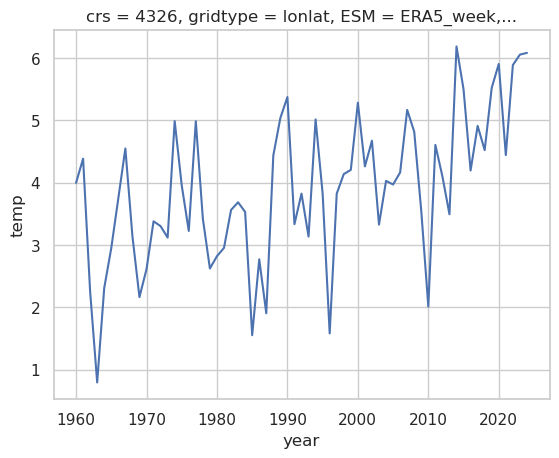

In [19]:
ts_datasets_ERA5['temp'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().plot()
# Filter for winter months (October to March)
# winter_months = [10, 11, 12, 1, 2, 3]
# winter_data = ts_datasets_ERA5['temp'].sel(time=ts_datasets_ERA5.time.dt.month.isin(winter_months))
# # Group by year and calculate the mean temperature for each winter season
# winter_season_means = winter_data.groupby('time.year').mean()
# # Plot the winter season means
# winter_season_means.plot()
# plt.title('Mean Winter Temperature (ERA5)')
# plt.xlabel('Year')
# plt.ylabel('Temperature (°C)')
# plt.grid()
# plt.show()


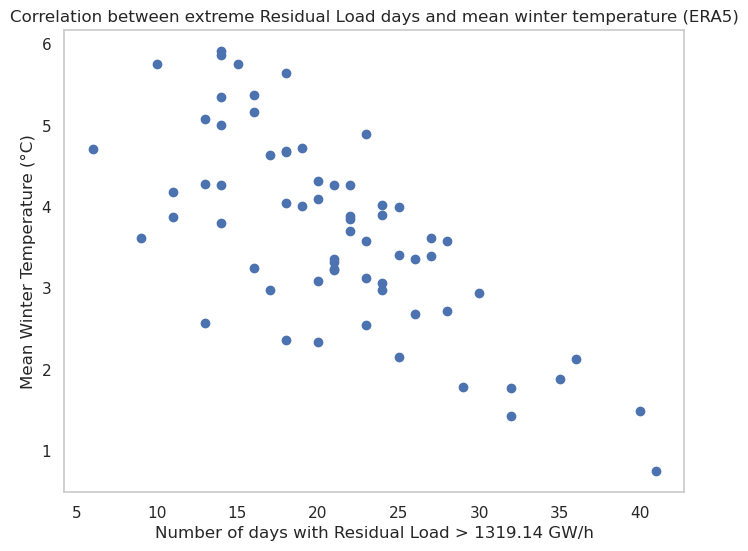

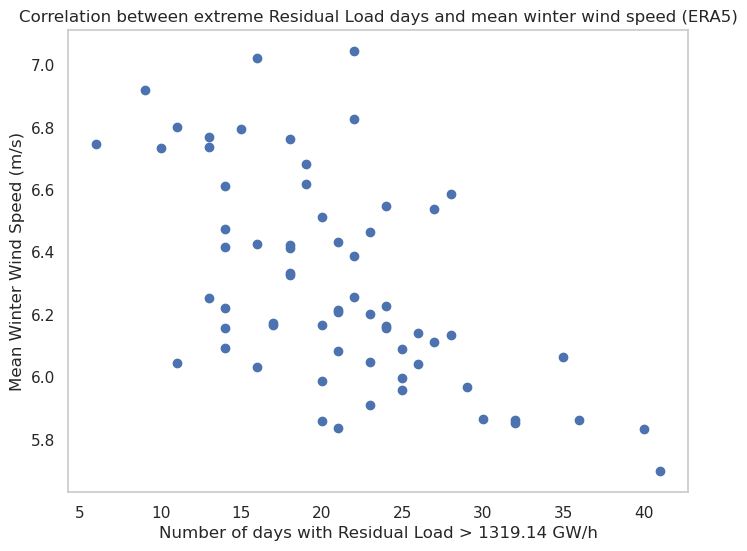

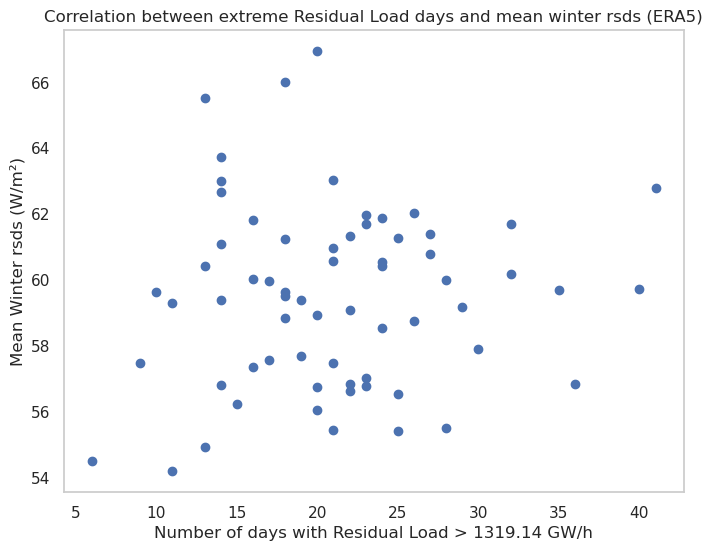

In [20]:
x = res_load_ERA5.groupby('time.year').apply(lambda x: np.sum(x > threshold)).values
y = ts_datasets_ERA5['tas'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().values

# Correalte and plot x and y
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Number of days with Residual Load > 1319.14 GW/h')
plt.ylabel('Mean Winter Temperature (°C)')
plt.title('Correlation between extreme Residual Load days and mean winter temperature (ERA5)')
plt.grid()
plt.show()

y = ts_datasets_ERA5['sfcWind'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().values

# Correalte and plot x and y
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Number of days with Residual Load > 1319.14 GW/h')
plt.ylabel('Mean Winter Wind Speed (m/s)')
plt.title('Correlation between extreme Residual Load days and mean winter wind speed (ERA5)')
plt.grid()
plt.show()

y = ts_datasets_ERA5['rsds'].sel(time=ts_datasets_ERA5.time.dt.month.isin([1,2,3,10,11,12])).groupby('time.year').mean().values
    
# Correalte and plot x and y
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.xlabel('Number of days with Residual Load > 1319.14 GW/h')
plt.ylabel('Mean Winter rsds (W/m²)')
plt.title('Correlation between extreme Residual Load days and mean winter rsds (ERA5)')
plt.grid()
plt.show()


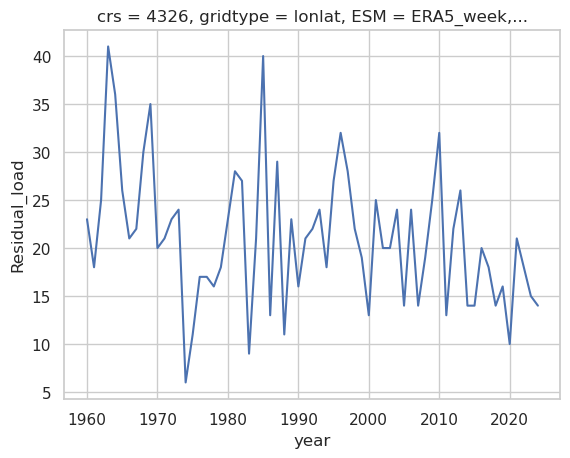

In [21]:
res_load_ERA5.groupby('time.year').apply(lambda x: np.sum(x > threshold)).plot()